# Chapter 3: Statistical Experiments and Significance Testing

## Summary

Statistical experiments and significance testing are fundamental tools used to determine whether observed differences in data are due to random chance or represent meaningful effects.

This chapter introduces A/B testing, hypothesis testing, permutation testing, p-values, Type I and Type II errors, and statistical significance. These concepts are widely used in data science, business analytics, scientific research, and machine learning evaluation.

Understanding statistical significance helps data scientists make evidence-based decisions and evaluate the effectiveness of changes, treatments, or predictive models.

## Learning Objectives

After completing this chapter, students should be able to:

- Understand statistical experiments.
- Explain A/B testing.
- Formulate null and alternative hypotheses.
- Interpret p-values.
- Understand Type I and Type II errors.
- Apply permutation testing.
- Explain statistical significance.
- Understand practical applications in data science.

## Theory: A/B Testing

A/B testing is a controlled experiment used to compare two versions of a system, webpage, product, or process.

Group A:
- Control Group

Group B:
- Treatment Group

The objective is to determine whether the treatment produces a statistically significant improvement.

Examples:

- Website design comparison
- Marketing campaigns
- Recommendation systems
- User interface optimization

A/B testing is one of the most widely used experimental methods in data-driven decision making.

In [1]:
import pandas as pd

ab_test = pd.DataFrame({
    'Group': ['A'] * 5 + ['B'] * 5,
    'Conversion': [10,12,11,13,12,15,18,16,17,19]
})

ab_test

,Group,Conversion
0,A,10
1,A,12
2,A,11
3,A,13
4,A,12
5,B,15
6,B,18
7,B,16
8,B,17
9,B,19


In [2]:
group_a = ab_test[
    ab_test['Group'] == 'A'
]['Conversion']

group_b = ab_test[
    ab_test['Group'] == 'B'
]['Conversion']

print("Group A Mean:")
print(group_a.mean())

print("\nGroup B Mean:")
print(group_b.mean())

Group A Mean:
11.6

Group B Mean:
17.0


## Code Explanation

The dataset simulates an A/B testing scenario.

Group A represents the control group, while Group B represents the treatment group.

The average conversion value is calculated for both groups to compare performance.

A higher average conversion in Group B may indicate a positive treatment effect, although statistical testing is required to determine significance.

## Theory: Hypothesis Testing

Hypothesis testing is a statistical procedure used to evaluate claims about a population.

### Null Hypothesis (H₀)

The null hypothesis assumes that no effect or difference exists.

Example:

There is no difference between Group A and Group B.

### Alternative Hypothesis (H₁)

The alternative hypothesis assumes that a meaningful difference exists.

Example:

There is a difference between Group A and Group B.

The goal of hypothesis testing is to determine whether sufficient evidence exists to reject the null hypothesis.

## Theory: Statistical Significance

Statistical significance indicates whether an observed result is unlikely to have occurred by random chance.

Researchers commonly use:

α = 0.05

Decision Rule:

- p-value < 0.05 → Reject H₀
- p-value ≥ 0.05 → Fail to Reject H₀

Statistical significance does not necessarily imply practical importance. Results should always be interpreted within context.

In [3]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    group_a,
    group_b
)

print("T Statistic:")
print(t_stat)

print("\nP Value:")
print(p_value)

T Statistic:
-6.194224814505168

P Value:
0.0002610663538074094


## Discussion

The A/B testing example demonstrates how statistical experiments are used to compare two groups.

The null hypothesis assumes no difference between the groups, while the alternative hypothesis assumes a meaningful difference.

The t-test evaluates whether the observed difference in average conversions could reasonably occur by chance.

Statistical significance helps organizations make data-driven decisions rather than relying solely on intuition.

## Theory: p-Value

The p-value measures the probability of observing data at least as extreme as the current results assuming that the null hypothesis is true.

Interpretation:

- Small p-value → Strong evidence against H₀
- Large p-value → Weak evidence against H₀

Common threshold:

p < 0.05

When the p-value is smaller than the significance level, the null hypothesis is rejected.

## Theory: Type I and Type II Errors

Hypothesis testing may lead to incorrect decisions.

### Type I Error

Rejecting a true null hypothesis.

Also known as:

False Positive

Example:

Concluding that a treatment works when it actually does not.

### Type II Error

Failing to reject a false null hypothesis.

Also known as:

False Negative

Example:

Concluding that a treatment does not work when it actually does.

Balancing these errors is an important part of experimental design.

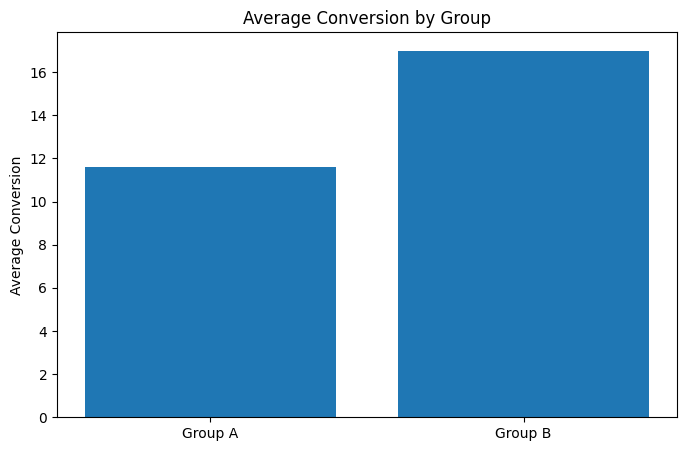

In [4]:
import matplotlib.pyplot as plt

means = [
    group_a.mean(),
    group_b.mean()
]

groups = [
    "Group A",
    "Group B"
]

plt.figure(figsize=(8,5))

plt.bar(
    groups,
    means
)

plt.title("Average Conversion by Group")
plt.ylabel("Average Conversion")

plt.show()

## Code Explanation

The bar chart compares the average conversion values of the control group and treatment group.

Visualizations provide a quick way to inspect differences before applying statistical tests.

Although Group B appears to have a higher average conversion, hypothesis testing is required to determine whether the difference is statistically significant.

## Theory: Permutation Testing

Permutation testing is a resampling technique used to evaluate whether observed differences between groups could occur by chance.

Procedure:

1. Combine observations from both groups.
2. Randomly shuffle labels.
3. Recalculate the difference.
4. Repeat many times.
5. Compare the observed difference with the generated distribution.

Permutation tests are useful because they make fewer assumptions than traditional parametric tests.

In [5]:
import numpy as np

observed_diff = (
    group_b.mean()
    -
    group_a.mean()
)

print("Observed Difference:")
print(observed_diff)

Observed Difference:
5.4


In [6]:
combined = np.concatenate([
    group_a,
    group_b
])

permuted_diffs = []

for i in range(1000):

    np.random.shuffle(combined)

    new_a = combined[:5]
    new_b = combined[5:]

    diff = (
        new_b.mean()
        -
        new_a.mean()
    )

    permuted_diffs.append(diff)

print("Permutation Test Complete")

Permutation Test Complete


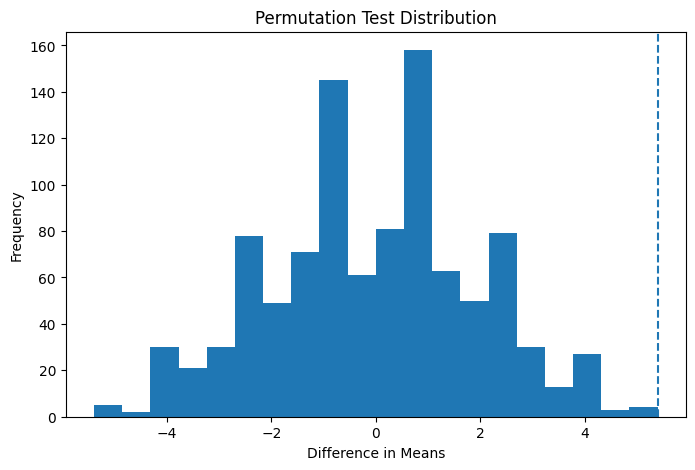

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    permuted_diffs,
    bins=20
)

plt.axvline(
    observed_diff,
    linestyle='--'
)

plt.title("Permutation Test Distribution")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")

plt.show()

## Discussion

Permutation testing provides an alternative approach to statistical significance testing.

Unlike traditional methods that rely on theoretical distributions, permutation testing uses repeated randomization to estimate the probability of observing a difference as large as the one measured.

This approach is widely used in modern data science because it is flexible and applicable to many experimental settings.

### Key Takeaways

- A/B testing compares control and treatment groups.
- Hypothesis testing evaluates claims using data.
- The p-value measures evidence against the null hypothesis.
- Type I and Type II errors represent incorrect decisions.
- Permutation tests provide a flexible alternative to classical testing.
- Statistical significance supports data-driven decision making.

## Theory: ANOVA (Analysis of Variance)

ANOVA is a statistical method used to compare the means of three or more groups.

The main objective is to determine whether at least one group mean differs significantly from the others.

### Null Hypothesis (H₀)

All group means are equal.

### Alternative Hypothesis (H₁)

At least one group mean is different.

ANOVA is widely used in business analytics, scientific experiments, and machine learning evaluation.

In [8]:
from scipy.stats import f_oneway

group1 = [10, 12, 11, 13, 12]
group2 = [15, 18, 16, 17, 19]
group3 = [20, 22, 21, 23, 24]

f_stat, p_value = f_oneway(
    group1,
    group2,
    group3
)

print("F Statistic:")
print(f_stat)

print("\nP Value:")
print(p_value)

F Statistic:
64.41269841269829

P Value:
3.828261309207485e-07


## Code Explanation

The ANOVA test compares the means of three groups simultaneously.

The F-statistic measures how much variation exists between groups relative to variation within groups.

A small p-value suggests that at least one group differs significantly from the others.

## Theory: Chi-Square Test

The Chi-Square Test is used to determine whether two categorical variables are related.

Examples:

- Gender and Product Preference
- Education Level and Employment Status
- Device Type and User Behavior

The test compares observed frequencies with expected frequencies under the assumption of independence.

In [9]:
from scipy.stats import chi2_contingency
import numpy as np

observed = np.array([
    [30, 20],
    [15, 35]
])

chi2, p, dof, expected = chi2_contingency(
    observed
)

print("Chi-Square Statistic:")
print(chi2)

print("\nP Value:")
print(p)

Chi-Square Statistic:
7.919191919191919

P Value:
0.004891311452359333


## Theory: Multi-Arm Bandit

The Multi-Arm Bandit problem is a decision-making framework used to balance:

- Exploration
- Exploitation

Exploration involves testing new options to gather information.

Exploitation involves selecting the currently best-performing option.

Multi-Arm Bandit algorithms are widely used in:

- Recommendation systems
- Online advertising
- Dynamic pricing
- Reinforcement learning

## Theory: Power and Sample Size

Statistical power is the probability of correctly rejecting a false null hypothesis.

Higher statistical power reduces the likelihood of Type II errors.

Factors affecting power:

- Sample size
- Effect size
- Significance level
- Data variability

Larger sample sizes generally increase statistical power and improve the reliability of experimental conclusions.

## Applications in Data Science

Statistical significance testing is widely used in modern data science.

Examples include:

### A/B Testing

Comparing website designs, advertisements, or product features.

### Model Comparison

Evaluating differences between machine learning models.

### Feature Selection

Determining whether variables significantly influence outcomes.

### Business Analytics

Supporting evidence-based decision making.

## Discussion

Statistical experiments provide a systematic framework for evaluating evidence and making decisions under uncertainty.

A/B testing, hypothesis testing, ANOVA, Chi-Square tests, and permutation tests allow analysts to distinguish meaningful effects from random variation.

These methods form the foundation of experimental design and support data-driven decision making across many domains.

Understanding significance testing is essential for evaluating business strategies, scientific discoveries, and machine learning systems.

## Conclusion

Statistical Experiments and Significance Testing are essential tools for evaluating evidence and making informed decisions.

This chapter introduced A/B testing, hypothesis testing, p-values, Type I and Type II errors, permutation testing, ANOVA, Chi-Square testing, and statistical power.

These concepts help data scientists determine whether observed effects are meaningful and provide a rigorous framework for experimental analysis.

A strong understanding of significance testing supports reliable decision making in both traditional statistics and modern machine learning applications.